# Exploration des données — Lignes de production industrielle

**Source :** [Synthetic Data from Industrial Sensor Monitoring](https://zenodo.org/records/15277168) — Polytechnic Institute of Porto / INESC TEC, avril 2025

**Objectif :** explorer les 5 fichiers CSV, identifier les anomalies, les différences de schéma et documenter les décisions d'architecture.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

DATA_DIR = Path("../data/raw")

FILES = {
    "lineA": "LineA_Stable_10K.csv",
    "lineB": "LineB_Flux.csv",
    "lineC": "LineC_Turbulent.csv",
    "lineD": "LineD_SpikeControl.csv",
    "lineE": "LineE_SmoothRun.csv",
}

## 1. Volumétrie

In [2]:
rows = []
for line, filename in FILES.items():
    path = DATA_DIR / filename
    df = pd.read_csv(path)
    rows.append({
        "ligne":      line,
        "fichier":    filename,
        "lignes":     len(df),
        "colonnes":   len(df.columns),
        "taille_ko":  round(path.stat().st_size / 1024, 1),
        "noms_colonnes": list(df.columns),
    })

vol = pd.DataFrame(rows)
print(vol[["ligne", "fichier", "lignes", "colonnes", "taille_ko"]].to_string(index=False))

ligne                fichier  lignes  colonnes  taille_ko
lineA   LineA_Stable_10K.csv   10000         5      757.5
lineB         LineB_Flux.csv    5000         5      381.5
lineC    LineC_Turbulent.csv    5000         4      288.1
lineD LineD_SpikeControl.csv    5000         4      288.2
lineE    LineE_SmoothRun.csv    5000         4      288.2


## 2. Hétérogénéité des schémas

In [3]:
print(f"{'Ligne':<8} {'Colonnes'}")
print("-" * 60)
for row in rows:
    print(f"{row['ligne']:<8} {row['noms_colonnes']}")

Ligne    Colonnes
------------------------------------------------------------
lineA    ['timestamp', 'Temperature', 'pressure', 'elapsed_time', 'label']
lineB    ['timestamp', 'temperature', 'pressure', 'Elapsed_time', 'label']
lineC    ['timestamp', 'Temperature', 'pressure', 'label']
lineD    ['timestamp', 'temperature', 'Pressure', 'label']
lineE    ['timestamp', 'Temperature', 'pressure', 'label']


In [4]:
# Tableau comparatif des variantes de nommage
schema_df = pd.DataFrame({
    "ligne":        [r["ligne"] for r in rows],
    "temperature":  [next((c for c in r["noms_colonnes"] if c.lower() == "temperature"), "ABSENT") for r in rows],
    "pressure":     [next((c for c in r["noms_colonnes"] if c.lower() == "pressure"),    "ABSENT") for r in rows],
    "elapsed_time": [next((c for c in r["noms_colonnes"] if c.lower() == "elapsed_time"),"ABSENT") for r in rows],
    "label":        [next((c for c in r["noms_colonnes"] if c.lower() == "label"),       "ABSENT") for r in rows],
})

schema_df

,ligne,temperature,pressure,elapsed_time,label
0,lineA,Temperature,pressure,elapsed_time,label
1,lineB,temperature,pressure,Elapsed_time,label
2,lineC,Temperature,pressure,ABSENT,label
3,lineD,temperature,Pressure,ABSENT,label
4,lineE,Temperature,pressure,ABSENT,label


**Observations :**
- `temperature` : présent partout mais avec une casse variable (`Temperature`, `temperature`)
- `pressure` : idem (`pressure`, `Pressure`)
- `elapsed_time` : présent uniquement sur LineA et LineB — **absent sur C, D, E**
- `label` : homogène sur toutes les lignes

**Décision :** normalisation complète en minuscules dans la couche STAGING, `elapsed_time` complété avec `NaN` pour les lignes qui ne l'ont pas.

## 3. Types et valeurs manquantes

In [5]:
for line, filename in FILES.items():
    df = pd.read_csv(DATA_DIR / filename)
    df.columns = [c.lower() for c in df.columns]
    print(f"\n{'='*40}")
    print(f"  {line} — {filename}")
    print(f"{'='*40}")
    info = pd.DataFrame({
        "type":      df.dtypes,
        "non_null":  df.count(),
        "manquants": df.isna().sum(),
    })
    print(info)


  lineA — LineA_Stable_10K.csv
                 type  non_null  manquants
timestamp      object     10000          0
temperature   float64     10000          0
pressure      float64     10000          0
elapsed_time  float64     10000          0
label           int64     10000          0

  lineB — LineB_Flux.csv
                 type  non_null  manquants
timestamp      object      5000          0
temperature   float64      5000          0
pressure      float64      5000          0
elapsed_time  float64      5000          0
label           int64      5000          0

  lineC — LineC_Turbulent.csv
                type  non_null  manquants
timestamp     object      5000          0
temperature  float64      5000          0
pressure     float64      5000          0
label          int64      5000          0

  lineD — LineD_SpikeControl.csv
                type  non_null  manquants
timestamp     object      5000          0
temperature  float64      5000          0
pressure     float64     

## 4. Statistiques descriptives

In [6]:
for line, filename in FILES.items():
    df = pd.read_csv(DATA_DIR / filename)
    df.columns = [c.lower() for c in df.columns]
    numeric_cols = [c for c in ["temperature", "pressure", "elapsed_time"] if c in df.columns]
    print(f"\n{line}")
    print(df[numeric_cols].describe().round(2))


lineA
       temperature  pressure  elapsed_time
count     10000.00  10000.00      10000.00
mean        180.01    160.00         35.00
std           0.25      0.19          0.22
min         179.49    156.80         34.27
25%         179.91    159.91         34.86
50%         180.00    160.00         35.00
75%         180.09    160.10         35.13
max         185.19    160.63         37.23

lineB
       temperature  pressure  elapsed_time
count      5000.00   5000.00       5000.00
mean        190.12    119.90         20.02
std           1.49      1.35          0.45
min         186.76    108.95         18.65
25%         189.35    119.28         19.74
50%         190.02    119.97         20.01
75%         190.68    120.67         20.28
max         202.72    123.53         22.98

lineC
       temperature  pressure
count      5000.00   5000.00
mean        200.45     99.63
std           2.71      2.22
min         194.65     88.32
25%         198.97     98.93
50%         200.11     99.92
75

## 5. Distribution du label (anomalies)

In [7]:
label_rows = []
for line, filename in FILES.items():
    df = pd.read_csv(DATA_DIR / filename)
    df.columns = [c.lower() for c in df.columns]
    counts = df["label"].value_counts().sort_index()
    total = len(df)
    nominal  = counts.get(0, 0)
    anomalie = counts.get(1, 0)
    label_rows.append({
        "ligne":           line,
        "nominal (0)":     nominal,
        "anomalie (1)":    anomalie,
        "% anomalie":      round(anomalie / total * 100, 2),
    })

pd.DataFrame(label_rows)

,ligne,nominal (0),anomalie (1),% anomalie
0,lineA,9982,18,0.18
1,lineB,4950,50,1.00
2,lineC,4800,200,4.00
3,lineD,4985,15,0.30
4,lineE,4975,25,0.50


## 6. Visualisation — température et pression par ligne

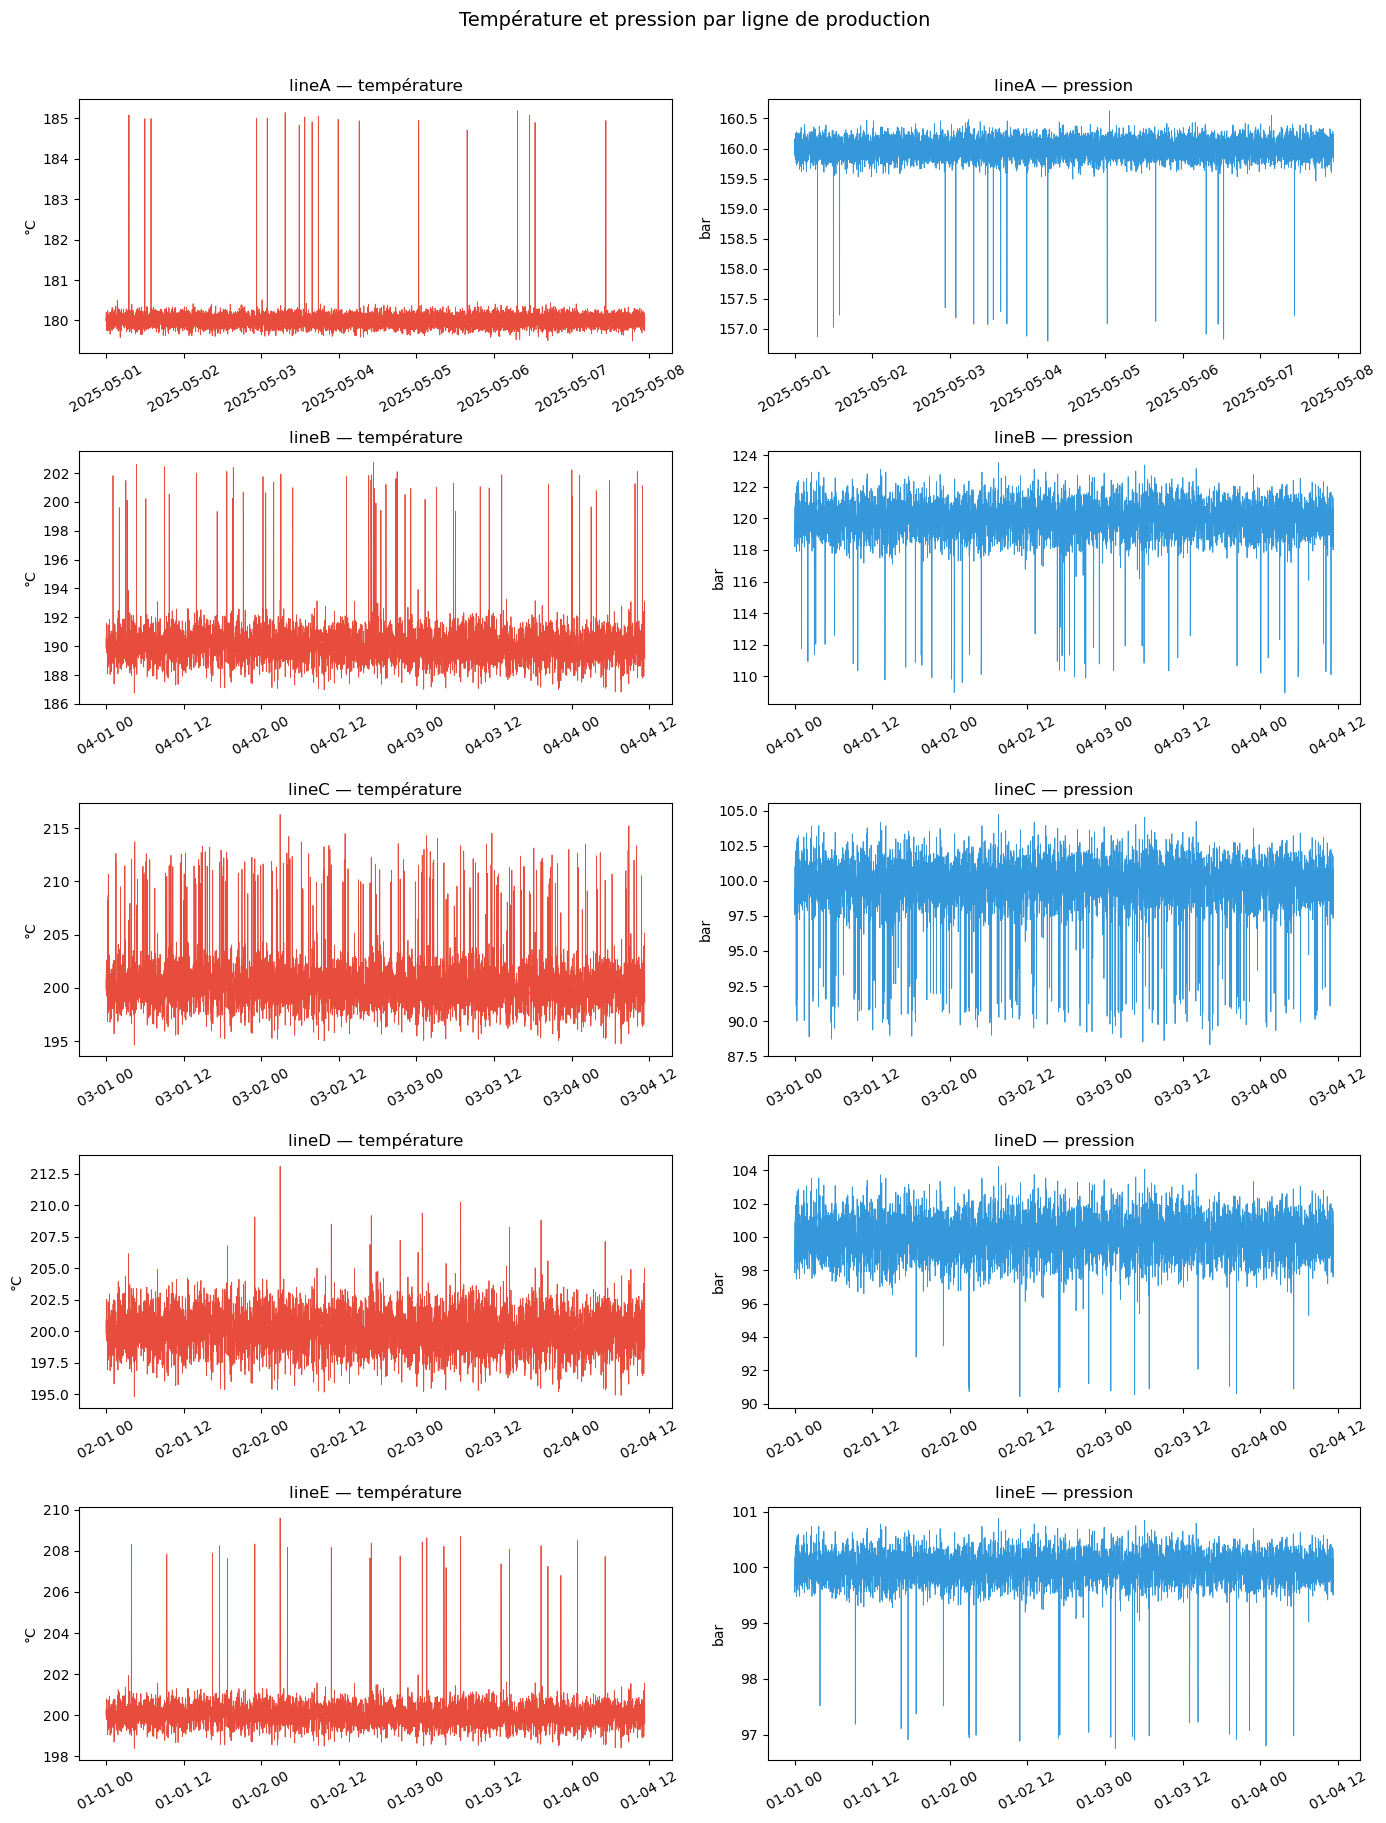

In [8]:
fig, axes = plt.subplots(5, 2, figsize=(14, 18))
fig.suptitle("Température et pression par ligne de production", fontsize=14, y=1.01)

for i, (line, filename) in enumerate(FILES.items()):
    df = pd.read_csv(DATA_DIR / filename)
    df.columns = [c.lower() for c in df.columns]
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Température
    axes[i, 0].plot(df["timestamp"], df["temperature"], linewidth=0.6, color="#e74c3c")
    axes[i, 0].set_title(f"{line} — température")
    axes[i, 0].set_ylabel("°C")
    axes[i, 0].tick_params(axis="x", rotation=30)

    # Pression
    axes[i, 1].plot(df["timestamp"], df["pressure"], linewidth=0.6, color="#3498db")
    axes[i, 1].set_title(f"{line} — pression")
    axes[i, 1].set_ylabel("bar")
    axes[i, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../docs/images/temperature_pression.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Visualisation — répartition des anomalies

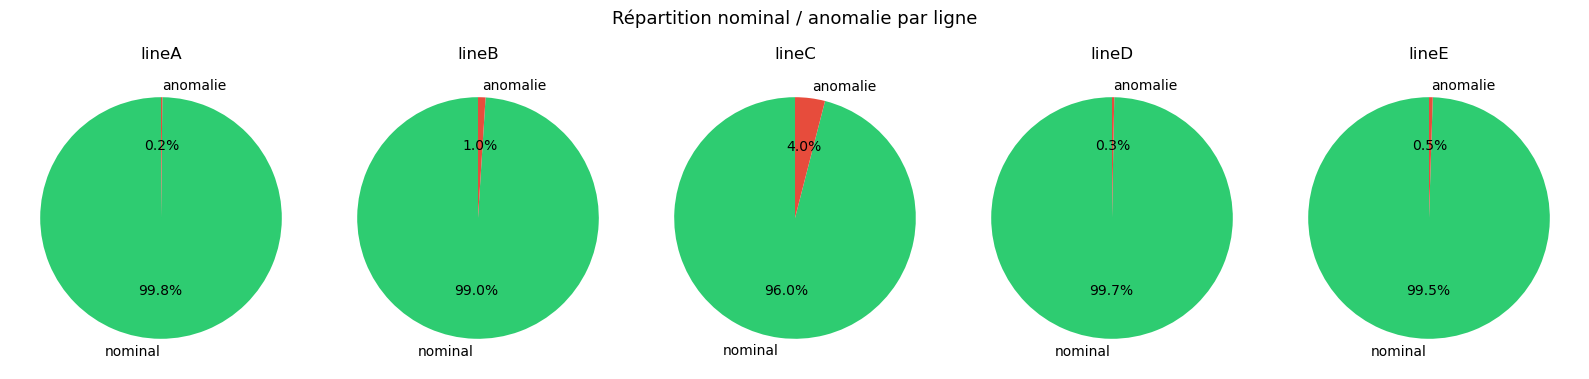

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle("Répartition nominal / anomalie par ligne", fontsize=13)

for i, (line, filename) in enumerate(FILES.items()):
    df = pd.read_csv(DATA_DIR / filename)
    df.columns = [c.lower() for c in df.columns]
    counts = df["label"].value_counts().sort_index()
    axes[i].pie(
        counts.values,
        labels=["nominal", "anomalie"] if len(counts) == 2 else ["nominal"],
        autopct="%1.1f%%",
        colors=["#2ecc71", "#e74c3c"],
        startangle=90,
    )
    axes[i].set_title(line)

plt.tight_layout()
plt.savefig("../docs/images/anomalies.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Synthèse

| Aspect | Observation |
|--------|-------------|
| Volumétrie | LineA est 2x plus volumineuse (10 000 enregistrements vs ~5 000) |
| Schémas | Casse des colonnes incohérente entre fichiers |
| elapsed_time | Absent sur LineC, D, E — sera rempli avec `NaN` en staging |
| Timestamps | Format homogène (`YYYY-MM-DD HH:MM:SS`) mais dates de début différentes par ligne |
| Anomalies | Champ `label` binaire : 0 = nominal, 1 = anomalie |

Ces observations fondent les décisions d'architecture décrites dans `docs/02_data_modelisation.md`.